In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import os

folder_path = 'datasets/retrofit/resampled'

dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
       
        df['timestamp'] = pd.to_datetime(df['timestamps'])
        
        df.drop(columns=['timestamps'], inplace=True)
        df.set_index('timestamp', inplace=True)
        df.sort_index(inplace=True)
        dfs.append(df)
dfs[0].head()  



,total_energy,pump_energy,hvac_energy,Tin,Tout,RH,month,PMV,PPD,Overall_Comfort
timestamp,,,,,,,,,,
2022-08-14 13:30:00,17.923451,0.0,0.0,26.663333,25.855000,43.000000,8,0.36,7.7,92.3
2022-08-14 13:45:00,9.999323,0.0,0.0,26.565926,25.663333,43.093333,8,0.33,7.3,92.7
2022-08-14 14:00:00,24.090146,0.0,0.0,26.500000,26.318667,43.490000,8,0.31,7.0,93.0
2022-08-14 14:15:00,40.105616,0.0,0.0,26.444444,26.343333,43.593333,8,0.29,6.8,93.2
2022-08-14 14:30:00,221.178375,0.0,0.0,26.332222,26.945333,43.990000,8,0.26,6.4,93.6


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn

test_start = pd.Timestamp('2023-01-22')
test_end = pd.Timestamp('2023-02-27')

df = dfs[0].copy()
# df = df.dropna()

unique_days = df.index.normalize().unique()
second_day = unique_days[4]


start = pd.to_datetime('2023-02-02 00:00:00')
end   = pd.to_datetime('2023-02-02 23:59:59')
df_day = df[(df.index >= start) & (df.index <= end)]

print(df_day.shape[0])
lags_out = [1, 2, 3, 4, 96]
for lag in lags_out:
    df[f'Tout_lag{lag}'] = df['Tout'].shift(lag)
# df['Tin_lag4'] = df['Tin'].shift(4)
df['Tout_lag1'] = df['Tout'].shift(1)
df['Tout_lag2'] = df['Tout'].shift(2)
df['Tin_lag4'] = df['Tin'].shift(4)
df['Tin_lag1'] = df['Tin'].shift(1)
df['Tin_lag2'] = df['Tin'].shift(2)
df['Tin_lag3'] = df['Tin'].shift(3)


df['Tin_target']  = df['Tin'].shift(-1).dropna()          
df['is_test'] = (df.index >= test_start) & (df.index <= test_end)
df['mode_heatcool'] = np.where(df['Tout'] > 15, 0, 1)

df['hvac_mode'] = 0 
on_mask = df['hvac_energy'] > 0
nonzero_power = df.loc[on_mask, 'hvac_energy']
bins = pd.qcut(nonzero_power, q=2, labels=[1, 2])
df.loc[on_mask, 'hvac_mode'] = bins.astype(int).values
df['hvac_mode_lag'] = df['hvac_mode'].shift(1)

df_on = df[df['hvac_energy'] > 0].copy()
nonzero_power = df_on['hvac_energy']
bins = pd.qcut(nonzero_power, q=2, labels=[1, 2])
df.loc[df['hvac_energy'] > 0, 'hvac_mode'] = bins.astype(int)
df_off = df[df.hvac_mode == 0].copy()

96


In [339]:
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_absolute_error, root_mean_squared_error
# from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LinearRegression
# from sklearn.linear_model import Ridge

feature_cols =  ['Tin', 'Tin_lag1','Tin_lag2','Tin_lag3', 'Tin_lag4', 'Tout']
df_lr = (
    df
    .loc[df.hvac_mode==0, ['Tin_target', 'is_test'] + feature_cols]
    .dropna(subset=['Tin_target'] + feature_cols)
)

df_lr_train = df_lr[~df_lr['is_test']]
df_lr_test = df_lr[df_lr['is_test']]

X_train = df_lr_train[feature_cols]
X_test = df_lr_test[feature_cols]
y_train = df_lr_train['Tin_target']
y_test = df_lr_test['Tin_target']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, shuffle=False 
# )

lr = LinearRegression()
lr.fit(X_train, y_train)
# lr = LinearRegression()
# lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(((y_test - y_pred)**2).mean())

print(f"LinearReg (HVAC off) → MAE: {mae:.3f} °C, RMSE: {rmse:.3f} °C")

LinearReg (HVAC off) → MAE: 0.071 °C, RMSE: 0.095 °C


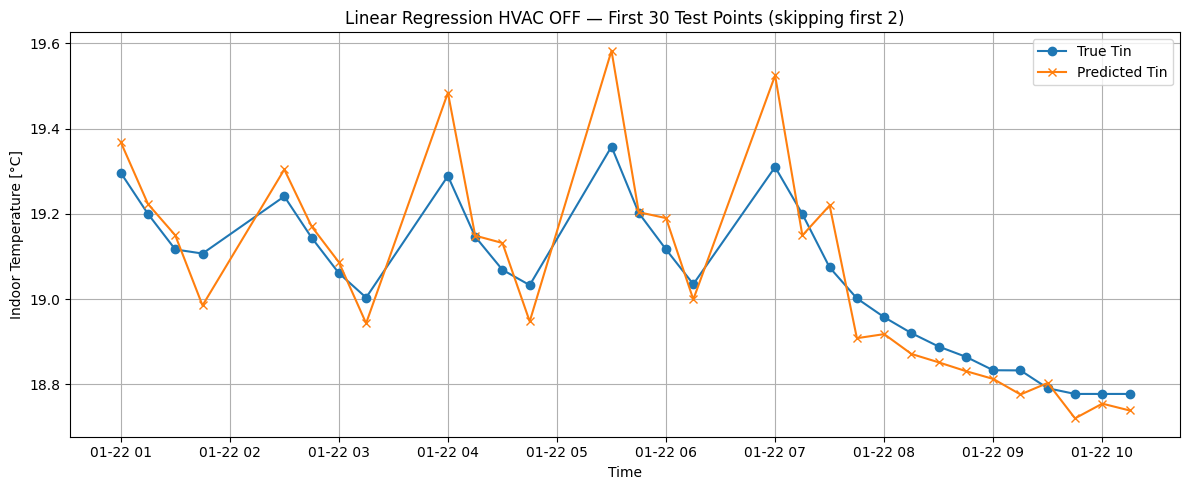

In [340]:
import matplotlib.pyplot as plt
results = pd.DataFrame({
    'Tin_true': y_test.values,
    'Tin_pred': y_pred,
}, index=df_lr_test.index)

N_skip = 2
N_plot = 30
plot_results = results.iloc[N_skip:N_skip+N_plot]

plt.figure(figsize=(12, 5))
plt.plot(plot_results.index, plot_results['Tin_true'], label='True Tin', marker='o')
plt.plot(plot_results.index, plot_results['Tin_pred'], label='Predicted Tin', marker='x')
plt.xlabel('Time')
plt.ylabel('Indoor Temperature [°C]')
plt.title(f'Linear Regression HVAC OFF — First {N_plot} Test Points (skipping first {N_skip})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

feature_cols = [
    'Tin',        
    'hvac_mode',
    # 'hvac_mode_lag',
    'Tin_lag1',
    'Tin_lag2',
    'Tin_lag3',
    'Tin_lag4',
    'Tout'
    # 'mode_heatcool',
    # 'Tin_lag2',
    # 'Tout'
]


df_on['Tin_target'] = df_on['Tin'].shift(-1)
df_on = df_on.dropna()
target_col = 'Tin_target'  

df_on_train = df_on[~df_on['is_test']]
df_on_test = df_on[df_on['is_test']]

X_train = df_on_train[feature_cols]
X_test = df_on_test[feature_cols]
y_train = df_on_train[target_col]
y_test = df_on_test[target_col]

# print(df_on.head(50))
# param_grid = {
#     'n_estimators': [100, 120, 160, 200, 300],
#     'max_depth': [4, 6, 8, 10, 12],
#     'learning_rate': [0.05, 0.07, 0.1, 0.2],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }

param_grid = {
    'n_estimators': [60, 80, 100, 120, 160],
    'max_depth': [6, 8, 10, 12],
    'min_samples_leaf': [1, 3, 5, 7],
    'min_samples_split': [2, 5]
}

tscv = TimeSeriesSplit(n_splits=5)
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
# rf = RandomForestRegressor(n_estimators=8, max_depth=9, random_state=42)
# grid = GridSearchCV(
#     xg,
#     param_grid,
#     cv=tscv,
#     scoring='neg_mean_absolute_error',
#     verbose=2,
#     n_jobs=-1
# )
grid = GridSearchCV(
    rf,
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error', 
    verbose=2,
    n_jobs=-1
)
# xg = XGBRegressor(
#     n_estimators=200,
#     max_depth=10,
#     learning_rate=0.04,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42
# )
grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)
print("Best CV MAE:", -grid.best_score_)
# xg.fit(X_train, y_train)
# rf.fit(X_train, y_train)

# y_pred = rf.predict(X_test)
# y_pred_xg = xg.predict(X_test)

y_true = y_test.values

y_pred = grid.best_estimator_.predict(X_test)
mae = np.mean(np.abs(y_pred - y_test))
mape = np.mean(np.abs((y_pred - y_test) / y_test)) * 100
print(f"Test MAE: {mae:.3f} °C")
print(f"Test MAPE: {mape:.3f} %")


Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best Params: {'max_depth': 12, 'min_samples_leaf': 7, 'min_samples_split': 5, 'n_estimators': 160}
Best CV MAE: 0.15625363838991096
Test MAE: 0.085 °C
Test MAPE: 0.423 %


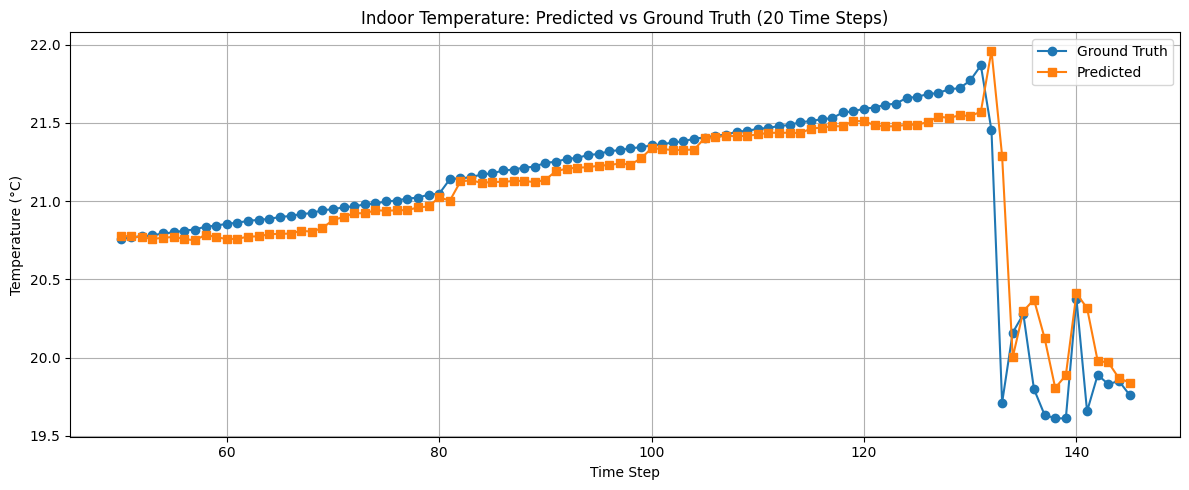

In [ ]:
import matplotlib.pyplot as plt

start_idx = 50
end_idx = start_idx + 96
y_true = y_test.values

y_plot = y_true[start_idx:end_idx]
y_pred_xg_plot = y_pred[start_idx:end_idx]

time_steps = list(range(start_idx, end_idx))

plt.figure(figsize=(12, 5))
plt.plot(time_steps, y_plot, label="Ground Truth", marker='o')
plt.plot(time_steps, y_pred_xg_plot, label="Predicted", marker='s')
plt.title("Indoor Temperature: Predicted vs Ground Truth (20 Time Steps)")
plt.xlabel("Time Step")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def predict_Tin_sequence_full(
    df_test,               
    window_start_idx,      
    lr_model,               
    rf_model,               
    n_steps=96              
):

    idxs = np.arange(window_start_idx, window_start_idx + n_steps)
    results = []

    lag_buffer = [
        df_test['Tin'].iloc[window_start_idx - 0], 
        df_test['Tin'].iloc[window_start_idx - 1],  
        df_test['Tin'].iloc[window_start_idx - 2], 
        df_test['Tin'].iloc[window_start_idx - 3],  
        df_test['Tin'].iloc[window_start_idx - 4],  
    ]

    for step, idx in enumerate(idxs):
        X_feat = lag_buffer.copy()
        hvac_mode = df_test['hvac_mode'].iloc[idx]
        Tout = df_test['Tout'].iloc[idx]

        if hvac_mode == 0:
            Tin_pred = lr_model.predict([X_feat + [Tout]])[0]
        else:
            Tin_pred = rf_model.predict([X_feat + [hvac_mode] + [Tout]])[0]

        results.append({
            'timestamp': df_test.index[idx],
            'Tin_pred': Tin_pred,
            'Tin_true': df_test['Tin'].iloc[idx],
            'hvac_mode': hvac_mode
        })

        lag_buffer = [Tin_pred] + lag_buffer[:-1]

    return pd.DataFrame(results).set_index('timestamp')

96


c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fit

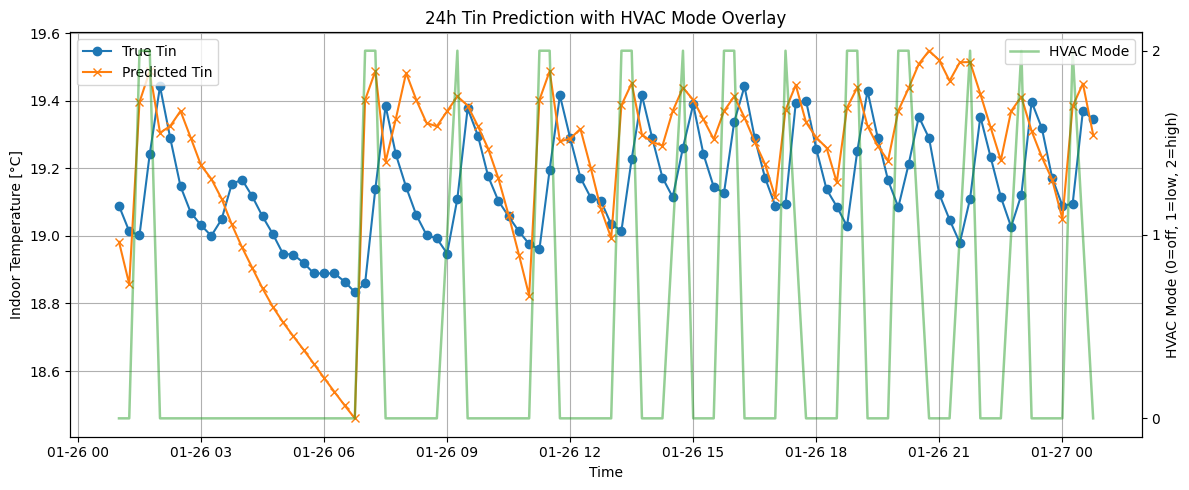

In [ ]:
df_test = df[df['is_test']].copy()
unique_days = df_test.index.normalize().unique()

second_day = unique_days[4]

start = pd.to_datetime('2023-02-02 00:00:00')
end   = pd.to_datetime('2023-02-02 23:59:59')
df_day = df_test[(df_test.index >= start) & (df_test.index <= end)]
df_day2 = df[(df.index >= start) & (df.index <= end)]

print(df_day2.shape[0])

target_date = pd.to_datetime('2023-02-02').date()
df_day = df_test[df_test.index.date == target_date]

second_day_mask = df_test.index.normalize() == second_day
df_second_day = df_test[second_day_mask]

window_length = 96  

window_start_idx = df_test.index.get_loc(df_second_day.index[4])  

results_24h = predict_Tin_sequence_full(
    df_test=df_test,
    window_start_idx=window_start_idx,
    lr_model=lr,
    rf_model=grid.best_estimator_,
    n_steps=window_length
)


fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(results_24h.index, results_24h['Tin_true'], label='True Tin', marker='o', color='tab:blue')
ax1.plot(results_24h.index, results_24h['Tin_pred'], label='Predicted Tin', marker='x', color='tab:orange')
ax1.set_xlabel('Time')
ax1.set_ylabel('Indoor Temperature [°C]')
ax1.legend(loc='upper left')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(results_24h.index, results_24h['hvac_mode'], label='HVAC Mode', color='tab:green', linewidth=1.8, alpha=0.5)
ax2.set_ylabel('HVAC Mode (0=off, 1=low, 2=high)')
ax2.set_yticks([0,1,2])
ax2.legend(loc='upper right')

plt.title('24h Tin Prediction with HVAC Mode Overlay')
plt.tight_layout()
plt.show()